In [ ]:
import torch
import numpy as np
import os
from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_dataset
from tqdm import tqdm
from joblib import Parallel, delayed
from dadapy import data
import argparse
import json
import matplotlib.pyplot as plt
%matplotlib inline
torch.set_grad_enabled(False)
print("Disabled automatic differentiation")

model_name = "meta-llama/Meta-Llama-3-8B"

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Load model with float16 (or bfloat16) if using GPU
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto"  # automatically use available GPUs
)
filtered_indices = np.load('filtered_indices.npy')

In [2]:
def shuffle_tokens(ids):
    assert ids.shape[0] == 1 and len(ids.shape) == 2, f"Expected shape (1, N), but got {ids.shape}"
    permutation = np.random.permutation(ids.shape[1])
    return ids[:, permutation]

def convert_to_distances(hs):
    return torch.stack([torch.cdist(item, item).squeeze() for item in hs])

def extract_hidden_states(sequence, model, tokenizer, max_length):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    inputs = tokenizer(sequence.strip() , add_special_tokens = False, \
                     return_tensors = "pt", max_length = max_length, \
                         truncation=True).to(device)
    outputs = model(**inputs, labels = inputs['input_ids'].clone(), \
                  output_hidden_states=True)
    hidden_states, loss = outputs.hidden_states, outputs.loss
    ans = {
          "hidden_distances" : convert_to_distances(hidden_states).cpu().detach().numpy(),\
          "loss": loss.to(torch.float32).cpu().detach().numpy(), \
          # "logit_distances": torch.cdist(outputs.logits, outputs.logits).cpu().detach().numpy().squeeze()
         }         
    return ans

def compute_ids(full_reps):
    ids = []
    for full_rep in full_reps:
        _, indices = np.unique(full_rep, axis=0, return_index=True)
        rep = full_rep[indices, :][:, indices]
        _data = data.Data(distances=rep, maxk=100)
        ids.append(_data.return_id_scaling_gride(range_max=64))
    return np.array(ids)

In [3]:
ds = load_dataset("NeelNanda/pile-10k")['train']
sequences = ds['text']
max_length = 1024

In [4]:
filtered_sequences = [sequences[idx] for idx in filtered_indices]

In [5]:
device = torch.device('cuda')

In [6]:
PNUM = 686 # prompt number 3218
sequence = filtered_sequences[PNUM]
ans = extract_hidden_states(sequence, model, tokenizer, max_length)
hidden_distances = ans['hidden_distances']
hidden_ids = compute_ids(hidden_distances)

In [7]:
inputs = tokenizer(sequence.strip(), add_special_tokens=False, return_tensors="pt",
                                       max_length=max_length, truncation=True).to(device)
ids = inputs['input_ids']
new_ids = shuffle_tokens(ids).to(device)
inputs = {'input_ids':new_ids}
outputs = model(**inputs, labels = inputs['input_ids'].clone(), output_hidden_states=True)
hidden_distances = convert_to_distances(outputs.hidden_states).cpu().detach().numpy()
hidden_shuffled_ids = compute_ids(hidden_distances)

In [ ]:
# Get vocab size
vocab_size = tokenizer.vocab_size
print(f"Vocab size: {vocab_size}")
all_vocab_ids = []
# Sample 1024 unique random token IDs
for _ in tqdm(range(20)):
    random_token_ids = torch.tensor([np.random.choice(vocab_size, size=1024, replace=False)]).to(device)
    inputs = {'input_ids':random_token_ids}
    outputs = model(**inputs, labels = inputs['input_ids'].clone(), output_hidden_states=True)
    hidden_distances = convert_to_distances(outputs.hidden_states).cpu().detach().numpy()
    vocab_shuffled_ids = compute_ids(hidden_distances)
    all_vocab_ids.append(vocab_shuffled_ids)
all_vocab_ids = np.array(all_vocab_ids)

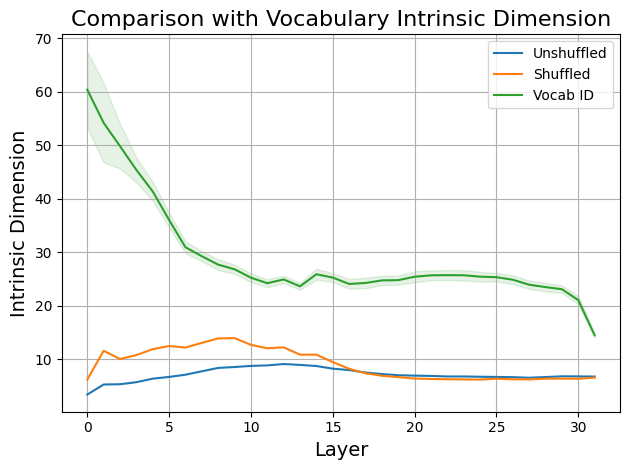

In [9]:
plt.plot(hidden_ids[1:, 0, 1], label = "Unshuffled"  )
plt.plot(hidden_shuffled_ids[1:, 0, 1], label = "Shuffled" )

# Extract values: shape [20, 1024]
values = all_vocab_ids[:, 1:, 0, 1]

# Compute mean and std across the 20 samples
mean_vals = values.mean(axis=0)
std_vals = values.std(axis=0)

plt.plot(mean_vals, label=f'Vocab ID')
plt.fill_between(np.arange(32), mean_vals - std_vals, mean_vals + std_vals, alpha=0.1, color= "green")

plt.xlabel("Layer", fontsize=14)
plt.ylabel("Intrinsic Dimension", fontsize=14)
plt.title("Comparison with Vocabulary Intrinsic Dimension", fontsize=16)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('vocab_comparison.png')
plt.show()